# Multi-Observation Grism Fitting Demo

This notebook demonstrates how to use geko's `run_geko_fit_multi()` function to jointly fit multiple grism observations.

## Overview

The multi-observation framework allows you to:
- Fit multiple R-dispersion observations at different position angles
- (Future) Fit R and C dispersion observations jointly
- Share galaxy parameters across observations while computing separate likelihoods

## Key Components

1. **run_geko_fit_multi()**: High-level wrapper function that handles everything
2. **observations_config**: List of dictionaries specifying each observation's parameters

This demo uses the same data twice to demonstrate the framework. In practice, you would use different observations at different position angles.

In [1]:
# Import necessary packages
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import numpyro

from geko.fitting import run_geko_fit_multi

# Configure JAX and Numpyro
jax.config.update('jax_enable_x64', True)
if 'gpu' in str(jax.devices()):
    print('Using GPU')
    numpyro.set_platform('gpu')
else:
    print('Using CPU')
    
numpyro.set_host_device_count(2)
numpyro.enable_validation()

print('JAX version:', jax.__version__)
print('Devices:', jax.devices())

Using CPU
JAX version: 0.6.1
Devices: [CpuDevice(id=0)]


## Step 1: Set up Parameters

In [2]:
# Set up paths
geko_path = '/Users/lola/geko/'  # Change this to your geko folder path

# Define parameters
source_id = 191250
field = 'manual'
output_name = 'my_galaxy'
master_catalog = geko_path + 'demo/simple_fit_demo_files/catalogs/my_galaxies_cat'
emission_line = 'H_alpha'
parametric = True
save_runs_path = geko_path + 'demo/simple_fit_demo_files/'

# Manual field parameters
manual_psf_name = 'webbPSF_F444W.fits'
manual_pysersic_file = 'summary_191250_image_F150W_svi.cat'
grism_file = 'spec_2d_FRESCO_F444W_ID191250_comb.fits'

# Processing parameters
grism_filter = 'F444W'
delta_wave_cutoff = 0.02
factor = 1  # Set low for demo speed (typically 5)
wave_factor = 1  # Set low for demo speed (typically 9)
model_name = 'Disk'

# MCMC parameters
num_chains = 1
num_warmup = 50  # Reduced for demo (use 500+ for real analysis)
num_samples = 50  # Reduced for demo (use 500+ for real analysis)

# Configure observations
# For this demo, we use the same observation twice with the same parameters
# In practice, you would specify different grism files at different position angles
observations_config = [
    {
        'grism_file': grism_file,
        'theta_rot': 0.0,  # rotation angle in degrees
        'dispersion': 'R',  # R (row) or C (column)
        'name': 'obs1'
    },
    {
        'grism_file': grism_file,  # Same file for demo
        'theta_rot': 0.0,  # Same angle for demo
        'dispersion': 'R',
        'name': 'obs2'
    }
]

print("Parameters set successfully")
print(f"Data directory: {save_runs_path}")
print(f"Source ID: {source_id}")
print(f"Observations to fit: {len(observations_config)}")

Parameters set successfully
Data directory: /Users/lola/geko/demo/simple_fit_demo_files/
Source ID: 191250
Observations to fit: 2


## Step 2: Run Multi-Observation Fitting

The `run_geko_fit_multi()` function handles:
1. Loading and preprocessing data for each observation
2. Creating GrismObservation objects
3. Setting up priors (from PySersic or config)
4. Running MCMC inference with shared parameters
5. Computing model predictions for each observation
6. Post-processing: computing v_re, v/sigma, saving fit results
7. Generating multi-observation summary plot

In [3]:
print("Running multi-observation fitting...")
print("This may take a few minutes...")
print()

# Run the multi-observation fitting
inf_data, results = run_geko_fit_multi(
    observations_config=observations_config,
    output=output_name,
    master_cat=master_catalog,
    line=emission_line,
    parametric=parametric,
    save_runs_path=save_runs_path,
    num_chains=num_chains,
    num_warmup=num_warmup,
    num_samples=num_samples,
    source_id=source_id,
    field=field,
    grism_filter=grism_filter,
    delta_wave_cutoff=delta_wave_cutoff,
    factor=factor,
    wave_factor=wave_factor,
    model_name=model_name,
    manual_psf_name=manual_psf_name,
    manual_pysersic_file=manual_pysersic_file
)

print("\nFitting complete!")
print(f"Results available for: {list(results.keys())}")

Running multi-observation fitting...
This may take a few minutes...

Running preprocessing on first observation...
Cont sub done
Flipping map! (Mod B)
(15, 15)
Module B detected: Flipping dispersion coefficient b01 from -1018.1000 to 1018.1000
Disk model created
Disk object created
Rotating the prior by  0.0  radians, from  2.964  radians to  2.964  radians
Setting parametric priors:  10.175309523224001 59.206811076802936 3.342 1.297 0.18970094750436658 15.165 15.0425

Creating 2 GrismObservation objects...
  Created: GrismObservation(name='obs1', theta_rot=0.0°, dispersion=R, shape=(31, 41))
  Loading observation obs2...
Cont sub done
Flipping map! (Mod B)
(15, 15)
Module B detected: Flipping dispersion coefficient b01 from -1018.1000 to 1018.1000
Disk model created
Disk object created
  Created: GrismObservation(name='obs2', theta_rot=0.0°, dispersion=R, shape=(31, 41))

Initializing Fit_Numpyro...

Generating prior predictive samples...

Fitting 2 observations jointly:
  - GrismObse

  0%|          | 0/100 [00:00<?, ?it/s]


Fitting 2 observations jointly:
  - GrismObservation(name='obs1', theta_rot=0.0°, dispersion=R, shape=(31, 41))
  - GrismObservation(name='obs2', theta_rot=0.0°, dispersion=R, shape=(31, 41))

Fitting 2 observations jointly:
  - GrismObservation(name='obs1', theta_rot=0.0°, dispersion=R, shape=(31, 41))
  - GrismObservation(name='obs2', theta_rot=0.0°, dispersion=R, shape=(31, 41))

Fitting 2 observations jointly:
  - GrismObservation(name='obs1', theta_rot=0.0°, dispersion=R, shape=(31, 41))
  - GrismObservation(name='obs2', theta_rot=0.0°, dispersion=R, shape=(31, 41))


sample: 100%|██████████| 100/100 [05:54<00:00,  3.54s/it, 31 steps of size 1.22e-01. acc. prob=0.93] 



MCMC complete!

                          mean       std    median      5.0%     95.0%     n_eff     r_hat
         unscaled_PA     -3.90      0.80     -3.95     -5.21     -2.78    589.17      0.98
   unscaled_PA_morph      0.20      1.05      0.29     -1.55      1.57     35.91      0.98
         unscaled_Va      0.70      0.02      0.70      0.67      0.73     30.14      0.98
  unscaled_amplitude      0.88      0.04      0.88      0.81      0.93    124.11      0.98
          unscaled_i      2.51      0.74      2.44      1.18      3.57     60.99      0.98
          unscaled_n     -0.91      0.02     -0.92     -0.93     -0.88     78.66      1.00
      unscaled_r_eff      0.91      0.03      0.91      0.86      0.95     67.68      0.98
        unscaled_r_t      0.56      0.07      0.56      0.42      0.64     33.86      0.98
     unscaled_sigma0      0.03      0.03      0.02      0.00      0.08     50.75      1.02
         unscaled_v0     -1.24      0.59     -1.19     -2.12     -0.35   

<Figure size 1000x1000 with 0 Axes>

## Step 5: Display the Auto-Generated Summary Plot

In [4]:
# Load and display the auto-generated multi-observation summary plot
from IPython.display import Image, display

summary_plot_path = f"{save_runs_path}{output_name}/summary_{source_id}_multi.png"
print(f"Loading summary plot from: {summary_plot_path}")
display(Image(filename=summary_plot_path))

Loading summary plot from: /Users/lola/geko/demo/simple_fit_demo_files/my_galaxy/summary_191250_multi.png


FileNotFoundError: [Errno 2] No such file or directory: '/Users/lola/geko/demo/simple_fit_demo_files/my_galaxy/summary_191250_multi.png'

## Step 6: MCMC Diagnostics

In [ ]:
## Step 6: MCMC Diagnostics

MCMC Trace Plots


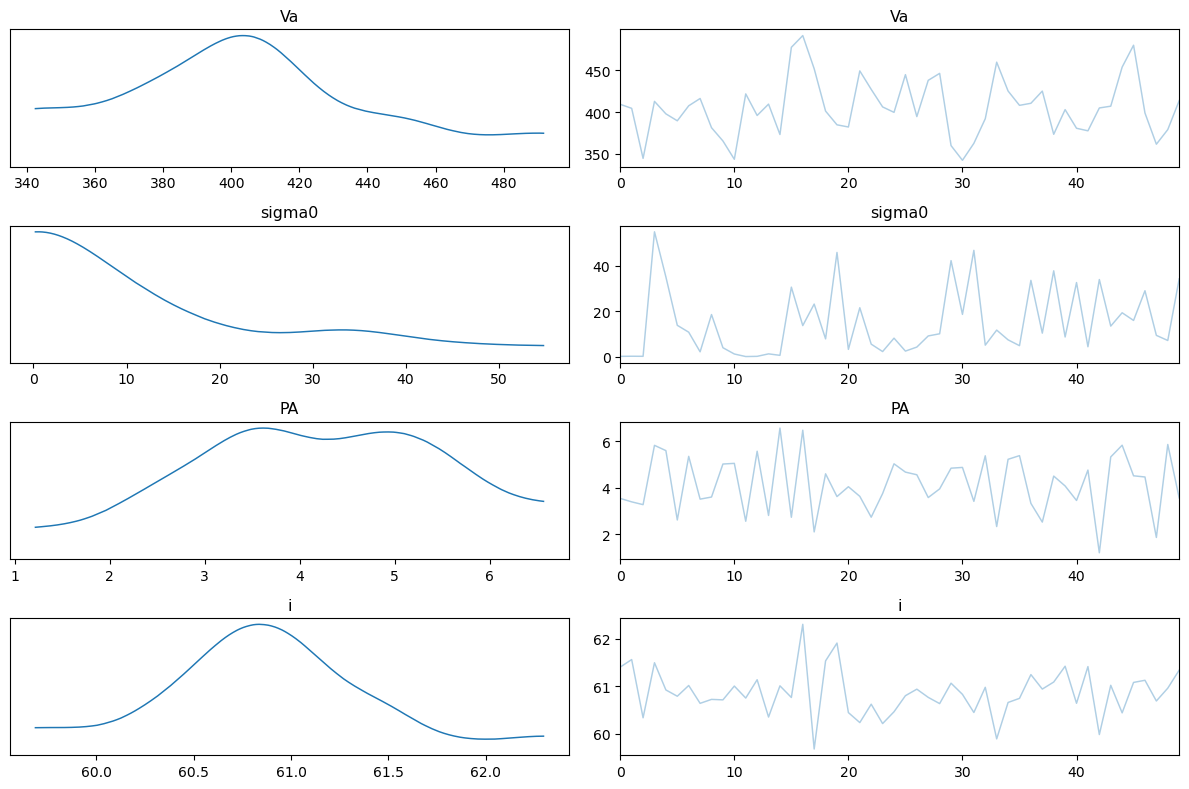

In [ ]:
# Trace plots for key parameters
print("MCMC Trace Plots")
print("="*60)
az.plot_trace(inf_data, var_names=['Va', 'sigma0', 'PA', 'i'])
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the simplified multi-observation fitting workflow using `run_geko_fit_multi()`:

1. ✓ Set up observation configurations (grism file, rotation angle, dispersion)
2. ✓ Call `run_geko_fit_multi()` with all parameters
3. ✓ **Automatic post-processing**: v_re, v/sigma computed and saved
4. ✓ **Automatic plot generation**: Multi-observation summary plot created
5. ✓ Analyze posterior statistics for shared parameters
6. ✓ (Optional) Create custom visualizations for each observation
7. ✓ Check MCMC diagnostics

## Key Advantages of `run_geko_fit_multi()`

- **Complete workflow**: Single function call handles everything from preprocessing to final plots
- **Shared parameters**: Galaxy parameters sampled once across all observations
- **Automatic post-processing**: Computes v_re, v/sigma, saves fit results, generates plots
- **Multi-observation summary plot**: Comprehensive visualization with N rows (one per observation) + 1 row for intrinsic fields
- **Clean results**: Returns inference data and model predictions in organized format

## Output Files Generated

- `{save_runs_path}/{output}/191250_output_multi`: Arviz InferenceData file (MCMC results)
- `{save_runs_path}/{output}/191250_fit_results.dat`: Fit results table with v_re and uncertainties
- `{save_runs_path}/{output}/summary_191250_multi.png`: Multi-observation summary plot

## Comparison with Single-Observation Fitting

**Single-observation** (`run_geko_fit()`):
- Fits one observation at a time
- Simpler for single position angle analysis
- Uses `plot_disk_summary()` for visualization

**Multi-observation** (`run_geko_fit_multi()`):
- Jointly fits multiple observations
- Better constraints from multiple viewing angles
- Shares parameters across observations
- Uses `plot_disk_summary_multi()` with dynamic row layout
- Useful for multi-PA or R+C dispersion data

## Next Steps

- Apply to real multi-angle observations at different `theta_rot` values
- Use longer chains for convergence (500+ samples, 500+ warmup)
- Compare results with single-observation fits
- (Future) Test with mixed R and C dispersion observations